Database from kaggle: https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

I'll analyze the relation with AI and anxiety, so first I need to know some information about the Dataframe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Setting options to display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv(r"/content/ai_student_impact_dataset (1).csv")

In [ ]:
#Which Major Category has the most students?

dependency = df.groupby('Major_Category')['Major_Category'].value_counts()
dependency

,count
Major_Category,
Arts,5933
Business,12538
Humanities,9994
Medical,6476
STEM,15059


Which group has better grades: Paid or Unpaid?

In [ ]:
#students that use AI has better grade?
students_grade_AI =df[df['Paid_Subscription'] == True]
Post_Semester_GPA = students_grade_AI['Post_Semester_GPA'].mean()

students_grade_wAI =df[df['Paid_Subscription'] == False]
Post_Semester_GPA_withoutAI = students_grade_wAI['Post_Semester_GPA'].mean()


**These data don't show a significant difference; I had to zoom in quite a bit to see the difference!!


---



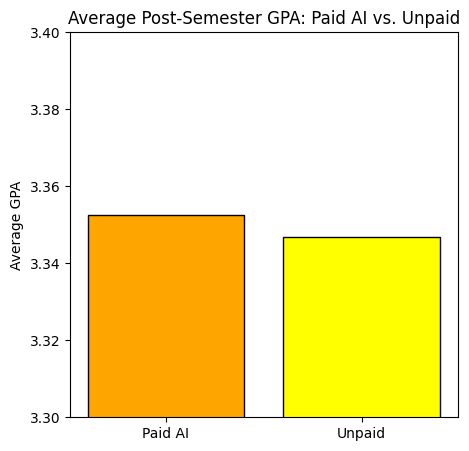

In [ ]:
#Plotting: Paid AI vs. Unpaid AI - Bar Chart
x_axis = ['Paid AI', 'Unpaid']
y_axis = [Post_Semester_GPA, Post_Semester_GPA_withoutAI]


plt.figure(figsize=(5,5))

plt.title('Average Post-Semester GPA: Paid AI vs. Unpaid')
plt.ylabel('Average GPA')

plt.ylim(3.30, 3.40) #look at this row!!!
plt.bar(x_axis,y_axis,color=['orange', 'yellow'], edgecolor='black')
plt.show()

And now, which group experiences more anxiety?

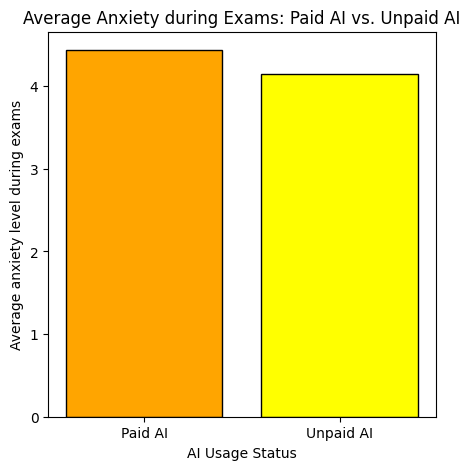

In [ ]:
#Anxiety with AI and Without AI

anxiety_ai_paid =df[df['Paid_Subscription'] == True]
anxiety_with_AI = anxiety_ai_paid['Anxiety_Level_During_Exams'].mean()

without_ai_anxiety =df[df['Paid_Subscription'] == False]
without_ai_level = without_ai_anxiety['Anxiety_Level_During_Exams'].mean()

x_axis = ['Paid AI', 'Unpaid AI']
y_axis = [anxiety_with_AI, without_ai_level]


plt.figure(figsize=(5,5))

plt.title('Average Anxiety during Exams: Paid AI vs. Unpaid AI')
plt.ylabel('Average anxiety level during exams')
plt.xlabel('AI Usage Status')

plt.bar(x_axis,y_axis,color=['orange', 'yellow'], edgecolor='black')
plt.show()

#Relation between anxiety and weekly genAI hours


/tmp/ipykernel_2250/3404534740.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  anxiety_by_hour = df.groupby('Hours_Group')['Anxiety_Level_During_Exams'].mean()


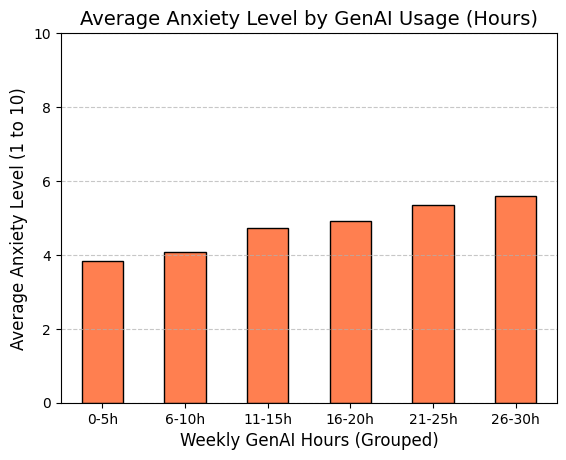

In [ ]:
#I'll split this code:
#Relation between anxiety and weekly genAI hours

hours_bins = [0, 5, 10, 15, 20, 25, 30]
hours_labels = ['0-5h', '6-10h', '11-15h', '16-20h', '21-25h', '26-30h']
df['Hours_Group'] = pd.cut(df['Weekly_GenAI_Hours'], bins=hours_bins, labels=hours_labels)
anxiety_by_hour = df.groupby('Hours_Group')['Anxiety_Level_During_Exams'].mean()
anxiety_by_hour.plot(kind='bar', color='coral', edgecolor='black')



plt.title('Average Anxiety Level by GenAI Usage (Hours)', fontsize=14)
plt.xlabel('Weekly GenAI Hours (Grouped)', fontsize=12)
plt.ylabel('Average Anxiety Level (1 to 10)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

plt.ylim(0, 10)

plt.show()


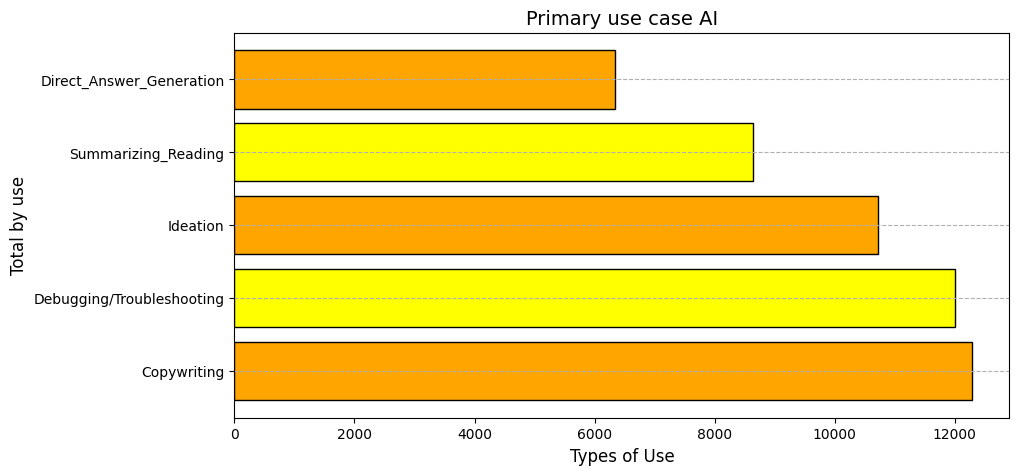

In [ ]:
use_case = df['Primary_Use_Case'].value_counts()
axis_y = use_case
axis_x = ['Copywriting', 'Debugging/Troubleshooting', 'Ideation','Summarizing_Reading','Direct_Answer_Generation']

plt.figure(figsize=(10,5))

plt.title('Primary use case AI', fontsize=14)
plt.xlabel('Types of Use', fontsize=12)
plt.ylabel('Total by use', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=1)

plt.barh(axis_x,axis_y,color=['orange', 'yellow'], edgecolor='black')



plt.show()

Do people who rely more on AI to generate direct responses feel more anxious?

In [ ]:
dependency = df.groupby('Primary_Use_Case')['Anxiety_Level_During_Exams'].mean()
dependency

,Anxiety_Level_During_Exams
Primary_Use_Case,
Copywriting/Drafting,4.199068
Debugging/Troubleshooting,4.334038
Direct_Answer_Generation,4.286435
Ideation,4.267419
Summarizing_Reading,4.273022


In [ ]:
Skill_and_use = df.groupby('Primary_Use_Case')['Skill_Retention_Score'].mean()
Skill_and_use

,Skill_Retention_Score
Primary_Use_Case,
Copywriting/Drafting,75.231097
Debugging/Troubleshooting,78.068964
Direct_Answer_Generation,73.718877
Ideation,75.520224
Summarizing_Reading,75.225024


This data reveals an important insight: the more hours students spend using AI, the higher their anxiety levels, which can be harmful to their mental health.